In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator
import seaborn as sns
import plotly.graph_objects as go

In [2]:
import sklearn
from sklearn import datasets
from sklearn.datasets import load_iris
print(sklearn.datasets.load_iris().DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [3]:
#laod the dataset
iris = datasets.load_iris()
X = pd.DataFrame(iris.data)
X.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
# laod the vector of target variable
y = iris.target
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

## LDA

### Checking LDA Assumptions on the Iris Dataset

LDA assumes that the feature data is normally distributed, variances are equal across groups, and that features are linearly related to the response variable.

#### Normality Check Using Shapiro-Wilk Test:
For each feature in the Iris dataset, the Shapiro-Wilk test assesses whether the data follows a normal distribution.

The Shapiro-Wilk test tests the null hypothesis that the data was drawn from a normal distribution.


[Detailed Documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html)

A low p-value (typically below 0.05) would suggest that the null hypothesis of normality can be rejected.

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Feature matrix
y = iris.target  # Target vector
feature_names = iris.feature_names  # Feature names
class_labels = iris.target_names  # Class names

# Perform Shapiro-Wilk test for each feature within each class
for class_label in np.unique(y):  # Iterate over each unique class label in the target vector
    print(f"Class: {class_labels[class_label]}")  # Print the name of the current class
    for i, feature_name in enumerate(feature_names):  # Iterate over each feature by index and name
        # Select data for the current class and feature
        class_data = X[y == class_label, i]
        # Apply the Shapiro-Wilk test to the feature values of the current class
        stat, p_value = shapiro(class_data)
        # Print the feature name and the p-value from the Shapiro-Wilk test
        print(f"Feature '{feature_name}' - p-value for normality: {p_value}")
    print("\n")  # Print a newline for better readability between classes


Class: setosa
Feature 'sepal length (cm)' - p-value for normality: 0.4595131499174534
Feature 'sepal width (cm)' - p-value for normality: 0.27152639563455816
Feature 'petal length (cm)' - p-value for normality: 0.05481146719553462
Feature 'petal width (cm)' - p-value for normality: 8.658572739428793e-07


Class: versicolor
Feature 'sepal length (cm)' - p-value for normality: 0.46473703592503574
Feature 'sepal width (cm)' - p-value for normality: 0.3379951061741208
Feature 'petal length (cm)' - p-value for normality: 0.15847783815657984
Feature 'petal width (cm)' - p-value for normality: 0.027277803876105258


Class: virginica
Feature 'sepal length (cm)' - p-value for normality: 0.2583147461407979
Feature 'sepal width (cm)' - p-value for normality: 0.18089604109070442
Feature 'petal length (cm)' - p-value for normality: 0.10977536903223795
Feature 'petal width (cm)' - p-value for normality: 0.0869541872909336





- **Feature Loop**: Within each class, another loop runs through each feature (sepal length, sepal width, petal length, petal width).

- **Normality Testing**:
  - For each feature within the current class, feature values are isolated.
  - The Shapiro-Wilk test is applied to these values.
  - A p-value is calculated, indicating whether the distribution of these values deviates from a normal distribution.

- **Output**:
  - For each feature within each class, a p-value is printed.
  - A lower p-value (typically below 0.05) indicates a potential violation of normality.

By checking the normal distribution of features within each species, we can validate the normality assumption crucial for LDA's optimality.


### Checking Homoscedasticity for LDA Using Bartlett's Test()

In [15]:
from scipy.stats import bartlett


# Apply Bartlett’s test to each feature across all classes
for i in range(X.shape[1]):  # Loop over each feature index
    # Extracting the feature data for each class
    sample1 = X[y == 0, i]  # Data for feature i where the class label is 0
    sample2 = X[y == 1, i]  # Data for feature i where the class label is 1
    sample3 = X[y == 2, i]  # Data for feature i where the class label is 2
    
    # Perform Bartlett's test for equal variances (homoscedasticity)
    stat, p_value = bartlett(sample1, sample2, sample3)
    # Output the results of Bartlett's test for the current feature
    print(f"Feature {i} - Bartlett test p-value: {p_value}")


Feature 0 - Bartlett test p-value: 0.0003345076070163035
Feature 1 - Bartlett test p-value: 0.35150280041580323
Feature 2 - Bartlett test p-value: 9.229037733034152e-13
Feature 3 - Bartlett test p-value: 3.0547839321996904e-09



To satisfy LDA's assumptions, the features should have equal variances across classes. We use Bartlett's test to check this assumption for the Iris dataset.

Here's how we perform the test for each feature:

- **Importing the Bartlett Test**:
  The `bartlett` function from `scipy.stats` is imported to conduct the homoscedasticity test.

- **Loop Through Each Feature**:
  We iterate over the indices of the features in `X` with `for i in range(X.shape[1])`.

- **Class-Specific Data Extraction**:
  For each feature index `i`, we extract data samples from `X` that correspond to each of the three classes (0, 1, 2).

- **Bartlett's Test Application**:
  `bartlett` is called with the class-specific data for the current feature to test for equal variances.

- **Results Output**:
  The p-value from the Bartlett test is printed, indicating whether the null hypothesis of equal variances is rejected. 
  
  A low p-value suggests that the feature does not have equal variances across the classes, which is a violation of the LDA assumptions.

Bartlett's test p-values guide us on whether a transformation or different approach might be necessary if homoscedasticity is not present.


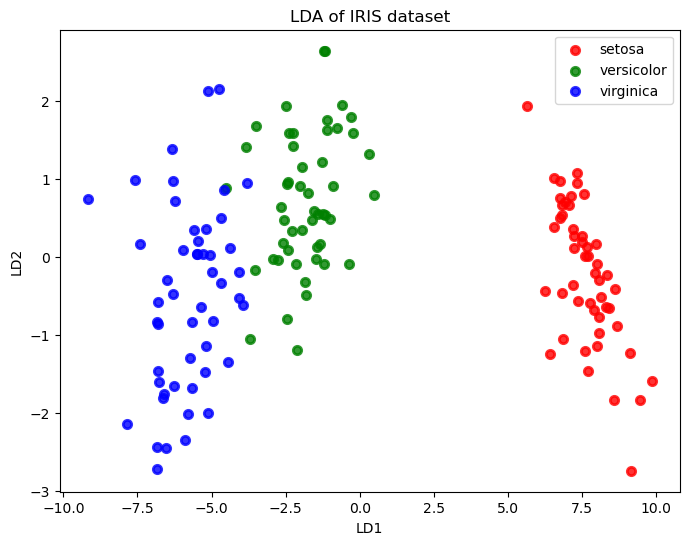

In [18]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Load the Iris dataset
data = load_iris()
X = data.data  # feature matrix
y = data.target  # target vector
target_names = data.target_names  # class names

# Initialize LDA with the number of components to produce
lda = LDA(n_components=2)
# Fit the LDA model to the data and transform it
X_lda = lda.fit_transform(X, y)

# Prepare a new figure with specified size for plotting
plt.figure(figsize=(8, 6))
# Define a list of colors for plotting each Iris species
colors = ['red', 'green', 'blue']
# Set the line width for the scatter plot
lw = 2

# Loop over each class (species) to scatter plot the LDA-transformed data
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    # Scatter plot for each class
    plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], alpha=0.8, color=color,
                label=target_name, lw=lw)

# Add a legend to the plot with best location
plt.legend(loc='best', shadow=False, scatterpoints=1)
# Title of the plot
plt.title('LDA of IRIS dataset')
# Label for x-axis
plt.xlabel('LD1')
# Label for y-axis
plt.ylabel('LD2')
# Display the plot
plt.show()


- **Import Libraries**:
  - `LinearDiscriminantAnalysis as LDA`: Import LDA for dimensionality reduction.

- **Load Dataset and Initialize LDA**:
  - Load the Iris dataset, which consists of 150 samples of iris flowers' features and target species labels.
  - Initialize an LDA object to reduce the data to two linear discriminants (LD1 and LD2).

- **LDA Transformation**:
  - Fit the LDA model on the feature data and class labels, transforming the data into a two-dimensional space optimized for class separation.

- **Prepare Visualization**:
  - Create a figure for plotting and set a list of colors for differentiating the three Iris species.

- **Plotting Loop**:
  - Iterate over each species and its corresponding color.
  - Create a scatter plot for each species in the transformed LDA space, using the specified colors and adding a label for the legend.


This visual representation allows us to observe how LDA maximizes class separability, which is crucial for classification tasks. Each species is distinctly clustered, demonstrating LDA's effectiveness in this context.



[Detailed Documentation ](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html)